## Modelagem

O tabuleiro 3x3 é numerado da seguinte forma:

```
1 2 3
4 5 6
7 8 9
```

- **Dicionário**: As peças `bx` e `by` são (brancas),`px` e `py` (pretas) e `None` para casa vazia.
- **Estado inicial**: `bx` na casa 1, `by` na casa 3, `px` na casa 7, `py` na casa 9.
- **Estado final**: peças pretas nas casas 1 e 3 e peças brancas nas casas 7 e 9, em qualquer combinação.
- **Regras de transição**: `RULES` define 16 regras (`r1` a `r16`), cada uma com um único movimento `(origem, destino)`; a regra só pode ser aplicada se a casa de origem tiver um cavalo e a casa de destino estiver vazia.

In [4]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("algorithms").resolve()))

from utils import INITIAL_STATE, is_goal, show_board

print("Estado inicial:")
show_board(INITIAL_STATE)

Estado inicial:
bx -- by
-- -- --
px -- py


## Backtracking

Busca em profundidade com limite `p`. Em cada nó escolhe a próxima regra ainda não tentada, em ordem crescente (`"asc"`, padrão) ou decrescente (`"desc"`). Se chegar ao limite, se `R(N)` ficar vazio, ou se o estado já estiver no caminho S–N, recua ao pai e tenta a próxima regra.

A célula abaixo imprime só o **caminho que deu certo**: em cada passo, as regras possíveis naquele estado, os recuos daquele nó e a regra aplicada.

Código: `algorithms/backtracking.py`

In [5]:
import importlib
import backtracking as bt

importlib.reload(bt)

P     = 36     # limite de profundidade (inteiro positivo)
ORDER = "asc"  # "asc"  → r1, r2, …, r16  |  "desc" → r16, r15, …, r1

result = bt.backtracking(INITIAL_STATE, depth_limit=P, order=ORDER)
if result is None:
    print(f"Fracasso: nenhuma solução encontrada com p = {P}, order = {ORDER!r}.")
else:
    path, applied, tried = result
    print(f"Sucesso! Solução com {len(applied)} movimentos (p = {P}, order = {ORDER!r}):")
    print(" -> ".join(applied))
    bt.print_solution(path, applied, tried)

Sucesso! Solução com 36 movimentos (p = 36, order = 'asc'):
r1 -> r5 -> r9 -> r2 -> r7 -> r11 -> r5 -> r13 -> r1 -> r7 -> r6 -> r3 -> r9 -> r11 -> r14 -> r16 -> r1 -> r3 -> r6 -> r7 -> r9 -> r5 -> r11 -> r1 -> r4 -> r7 -> r10 -> r11 -> r13 -> r1 -> r6 -> r10 -> r13 -> r16 -> r4 -> r7

Estado inicial:
bx -- by
-- -- --
px -- py

Passo 1: r1 (1 -> 6)
  possibilidades: r1, r2, r5, r6, r11, r12, r15, r16
  recuos neste nó: (nenhuma)
  aplica r1
-- -- by
-- -- bx
px -- py

Passo 2: r5 (3 -> 4)
  possibilidades: r5, r6, r11, r15, r16
  recuos neste nó: (nenhuma)
  aplica r5
-- -- --
by -- bx
px -- py

Passo 3: r9 (6 -> 1)
  possibilidades: r9, r11, r15
  recuos neste nó: (nenhuma)
  aplica r9
bx -- --
by -- --
px -- py

Passo 4: r2 (1 -> 8)
  possibilidades: r2, r11, r12, r15
  recuos neste nó: (nenhuma)
  aplica r2
-- -- --
by -- --
px bx py

Passo 5: r7 (4 -> 3)
  possibilidades: r7, r11, r12, r14, r15
  recuos neste nó: (nenhuma)
  aplica r7
-- -- by
-- -- --
px bx py

Passo 6: r11 (7 -> 

## BFS

Busca em largura seguindo o Algoritmo Básico de Busca, com `abertos` como **Fila** e `fechados` para descartar estados já vistos. Como expande os nós por níveis, garante a solução com o **menor número de movimentos**. A escolha de `r` em `R(N)` segue a ordem crescente (`"asc"`, padrão) ou decrescente (`"desc"`).

A célula abaixo imprime o caminho encontrado: em cada passo, as regras possíveis naquele estado e a regra aplicada.

Código: `algorithms/bfs.py`

In [6]:
import importlib
import bfs

importlib.reload(bfs)

ORDER = "asc"  # "asc"  → r1, r2, …, r16  |  "desc" → r16, r15, …, r1

result = bfs.bfs(INITIAL_STATE, order=ORDER)
if result is None:
    print(f"Fracasso: abertos esvaziou sem encontrar solução (order = {ORDER!r}).")
else:
    path, applied, stats, parent = result
    print(f"Sucesso! Solução ótima com {len(applied)} movimentos "
          f"({stats['expanded']} nós expandidos, máx. de abertos = {stats['max_open']}, order = {ORDER!r}):")
    print(" -> ".join(applied))
    bfs.print_solution(path, applied, order=ORDER)

Sucesso! Solução ótima com 16 movimentos (273 nós expandidos, máx. de abertos = 29, order = 'asc'):
r1 -> r6 -> r11 -> r10 -> r13 -> r1 -> r16 -> r4 -> r7 -> r6 -> r11 -> r10 -> r13 -> r16 -> r4 -> r7

Estado inicial:
bx -- by
-- -- --
px -- py

Passo 1: r1 (1 -> 6)
  possibilidades: r1, r2, r5, r6, r11, r12, r15, r16
  aplica r1
-- -- by
-- -- bx
px -- py

Passo 2: r6 (3 -> 8)
  possibilidades: r5, r6, r9, r11, r15, r16
  aplica r6
-- -- --
-- -- bx
px by py

Passo 3: r11 (7 -> 2)
  possibilidades: r9, r11, r13, r14, r15, r16
  aplica r11
-- px --
-- -- bx
-- by py

Passo 4: r10 (6 -> 7)
  possibilidades: r3, r9, r10, r13, r14, r16
  aplica r10
-- px --
-- -- --
bx by py

Passo 5: r13 (8 -> 1)
  possibilidades: r12, r13, r14, r16
  aplica r13
by px --
-- -- --
bx -- py

Passo 6: r1 (1 -> 6)
  possibilidades: r1, r2, r12, r16
  aplica r1
-- px --
-- -- by
bx -- py

Passo 7: r16 (9 -> 4)
  possibilidades: r9, r16
  aplica r16
-- px --
py -- by
bx -- --

Passo 8: r4 (2 -> 9)
  possibilid

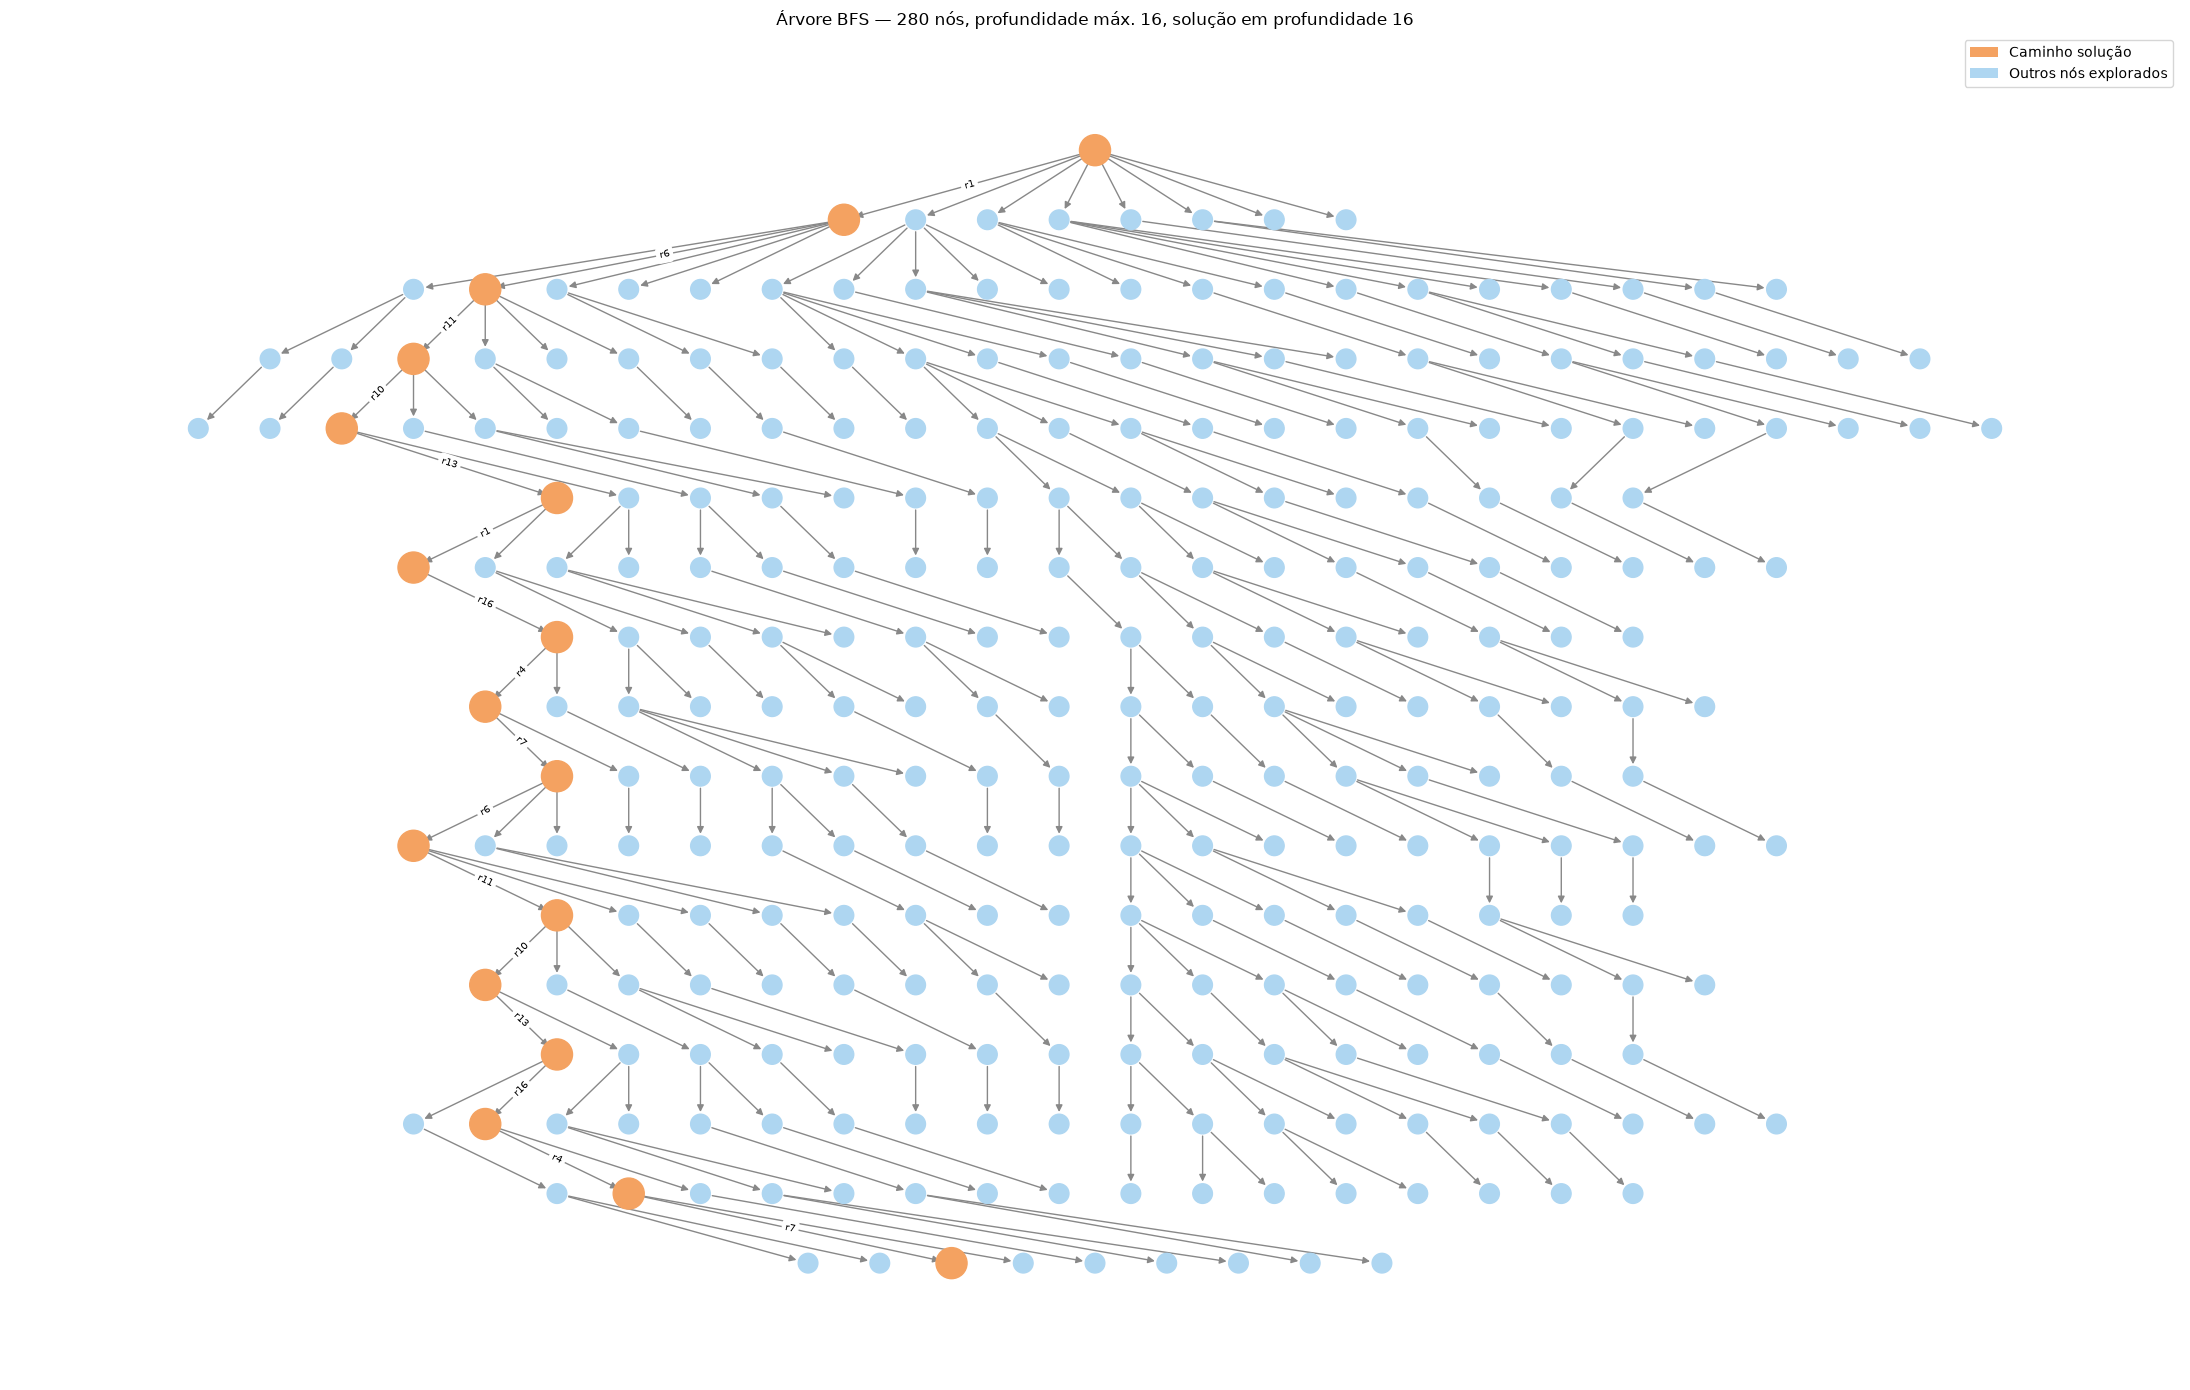

In [7]:
bfs.plot_tree(path, parent, order=ORDER)